# World Cup 2026 Predictor - Model Analysis

This notebook analyzes trained models, compares performance, and evaluates feature importance.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import PROCESSED_DIR
from src.models.evaluate import evaluate_model, compare_models, plot_calibration_curves
from src.models.train import split_data

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

## 1. Load Data

In [2]:
models_dir = PROCESSED_DIR / 'models'
feature_cols = joblib.load(models_dir / 'feature_columns.joblib')
print(f'Feature columns ({len(feature_cols)}): {feature_cols}')

Feature columns (80): ['elo_home', 'elo_away', 'elo_delta', 'elo_abs_delta', 'elo_home_win_prob', 'elo_draw_prob', 'elo_away_win_prob', 'fifa_rank_home', 'fifa_rank_away', 'fifa_rank_delta', 'fifa_rank_abs_delta', 'fifa_points_home', 'fifa_points_away', 'fifa_points_delta', 'fifa_points_abs_delta', 'neutral', 'home_advantage', 'is_host_nation', 'same_confederation', 'is_world_cup', 'is_qualifier', 'is_friendly', 'is_knockout', 'combined_draw_prob', 'elo_close', 'draw_tendency', 'fifa_close', 'home_form_last10_win_rate', 'home_form_last10_draw_rate', 'home_form_last10_loss_rate', 'home_form_last10_goals_scored_avg', 'home_form_last10_goals_conceded_avg', 'home_form_last10_goal_diff_avg', 'home_form_last10_clean_sheet_rate', 'home_form_last5_win_rate', 'home_form_last5_draw_rate', 'home_form_last5_loss_rate', 'home_form_last5_goals_scored_avg', 'home_form_last5_goals_conceded_avg', 'home_form_last5_goal_diff_avg', 'home_form_last5_clean_sheet_rate', 'away_form_last10_win_rate', 'away_for

In [3]:
features_path = PROCESSED_DIR / 'match_features.parquet'
df = pd.read_parquet(features_path)
df = df.dropna(subset=['outcome'])

(X_train, y_train, X_val, y_val, X_test, y_test,
 feature_cols, train_df, val_df, test_df) = split_data(df)

print(f'Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}')

2026-07-01 11:39:25,956 [INFO] worldcup: Splitting data...
2026-07-01 11:39:25,971 [INFO] worldcup: Train: 45807 | Val: 1054 | Test: 2552


Train: 45807 | Val: 1054 | Test: 2552


## 2. Individual Model Comparison

Load and evaluate each model one at a time to keep memory low, then free it.

In [4]:
all_results = {}
model_names_map = {
    'logisticregression': 'LogisticRegression',
    'neuralnet': 'NeuralNet',
    'randomforest': 'RandomForest',
    'xgboost': 'XGBoost',
}

for filename, display_name in model_names_map.items():
    model_path = models_dir / f'{filename}.joblib'
    if not model_path.exists():
        print(f'Skipping {display_name} (not found)')
        continue
    model = joblib.load(model_path)
    results = evaluate_model(model, X_test, y_test, display_name)
    all_results[display_name] = results
    print(f'{display_name}: acc={results["accuracy"]:.4f}, log_loss={results["log_loss"]:.4f}')
    del model

comparison = compare_models(all_results)
comparison

2026-07-01 11:39:26,179 [INFO] worldcup: Evaluating LogisticRegression...
2026-07-01 11:39:26,185 [INFO] worldcup:   Accuracy: 0.5792
2026-07-01 11:39:26,185 [INFO] worldcup:   Log Loss: 0.8739
2026-07-01 11:39:26,186 [INFO] worldcup:   Brier Scores: {'away_win': 0.1462019979953766, 'draw': 0.18053273856639862, 'home_win': 0.18888862431049347}
2026-07-01 11:39:26,190 [INFO] worldcup: Evaluating NeuralNet...
2026-07-01 11:39:26,196 [INFO] worldcup:   Accuracy: 0.3589
2026-07-01 11:39:26,196 [INFO] worldcup:   Log Loss: 1.7322
2026-07-01 11:39:26,197 [INFO] worldcup:   Brier Scores: {'away_win': 0.22169771790504456, 'draw': 0.42681941390037537, 'home_win': 0.3043896555900574}


LogisticRegression: acc=0.5792, log_loss=0.8739
NeuralNet: acc=0.3589, log_loss=1.7322


2026-07-01 11:39:26,592 [INFO] worldcup: Evaluating RandomForest...
2026-07-01 11:39:26,672 [INFO] worldcup:   Accuracy: 0.5933
2026-07-01 11:39:26,672 [INFO] worldcup:   Log Loss: 0.8573
2026-07-01 11:39:26,672 [INFO] worldcup:   Brier Scores: {'away_win': 0.14666325202383018, 'draw': 0.1765132746880259, 'home_win': 0.18110421569620472}
2026-07-01 11:39:26,684 [INFO] worldcup: Evaluating XGBoost...
2026-07-01 11:39:26,693 [INFO] worldcup:   Accuracy: 0.5047
2026-07-01 11:39:26,693 [INFO] worldcup:   Log Loss: 0.9553
2026-07-01 11:39:26,694 [INFO] worldcup:   Brier Scores: {'away_win': 0.16021974384784698, 'draw': 0.2270670384168625, 'home_win': 0.19388972222805023}
2026-07-01 11:39:26,694 [INFO] worldcup: Comparing models...
2026-07-01 11:39:26,698 [INFO] worldcup: 
             Model  Accuracy  Log Loss  Brier (home_win)  Brier (draw)  Brier (away_win)  Avg Brier
      RandomForest  0.593260  0.857292          0.181104      0.176513          0.146663   0.168094
LogisticRegression  0.

RandomForest: acc=0.5933, log_loss=0.8573
XGBoost: acc=0.5047, log_loss=0.9553


,Model,Accuracy,Log Loss,Brier (home_win),Brier (draw),Brier (away_win),Avg Brier
2,RandomForest,0.593260,0.857292,0.181104,0.176513,0.146663,0.168094
0,LogisticRegression,0.579154,0.873891,0.188889,0.180533,0.146202,0.171874
3,XGBoost,0.504702,0.955328,0.193890,0.227067,0.160220,0.193726
1,NeuralNet,0.358934,1.732182,0.304390,0.426819,0.221698,0.317636


2026-07-01 11:39:26,755 [INFO] worldcup: Plotting model comparison...


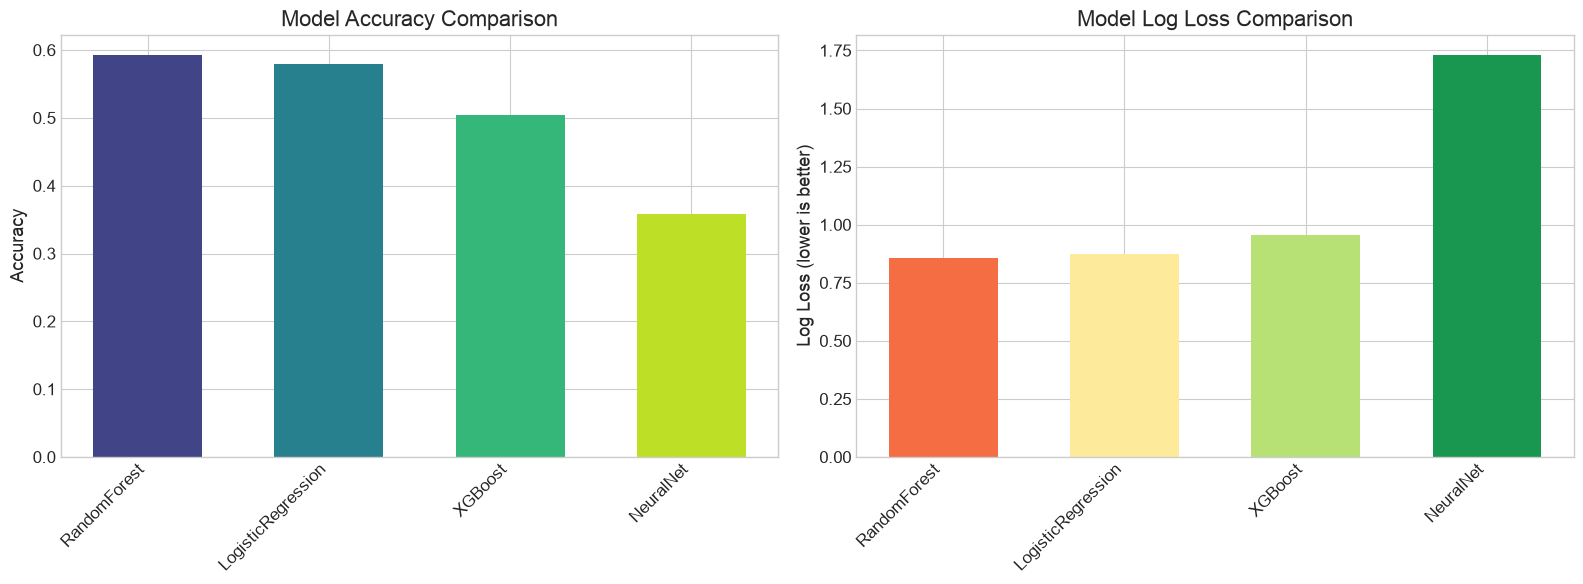

In [5]:
from src.visualization.plots import plot_model_comparison
plot_model_comparison(comparison, save=False)
plt.show()

## 3. Feature Importance

2026-07-01 11:39:27,012 [INFO] worldcup: Plotting feature importance...


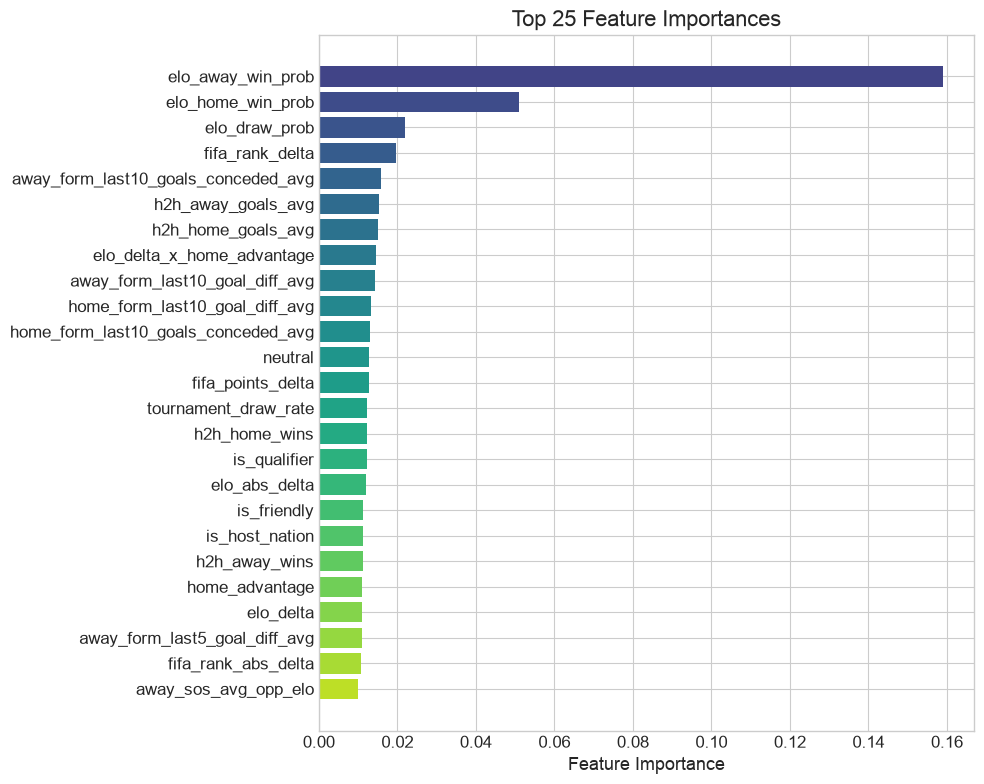

In [6]:
from src.visualization.plots import plot_feature_importance

xgb_model = joblib.load(models_dir / 'xgboost.joblib')
plot_feature_importance(xgb_model, feature_cols, top_n=25, save=False)
plt.show()
del xgb_model

## 4. Probability Calibration

2026-07-01 11:39:27,146 [INFO] worldcup: Plotting calibration curves...
2026-07-01 11:39:27,357 [INFO] worldcup:   Saved to /Users/sithea/Documents/code/worldcup/data/processed/evaluation/calibration_curves.png


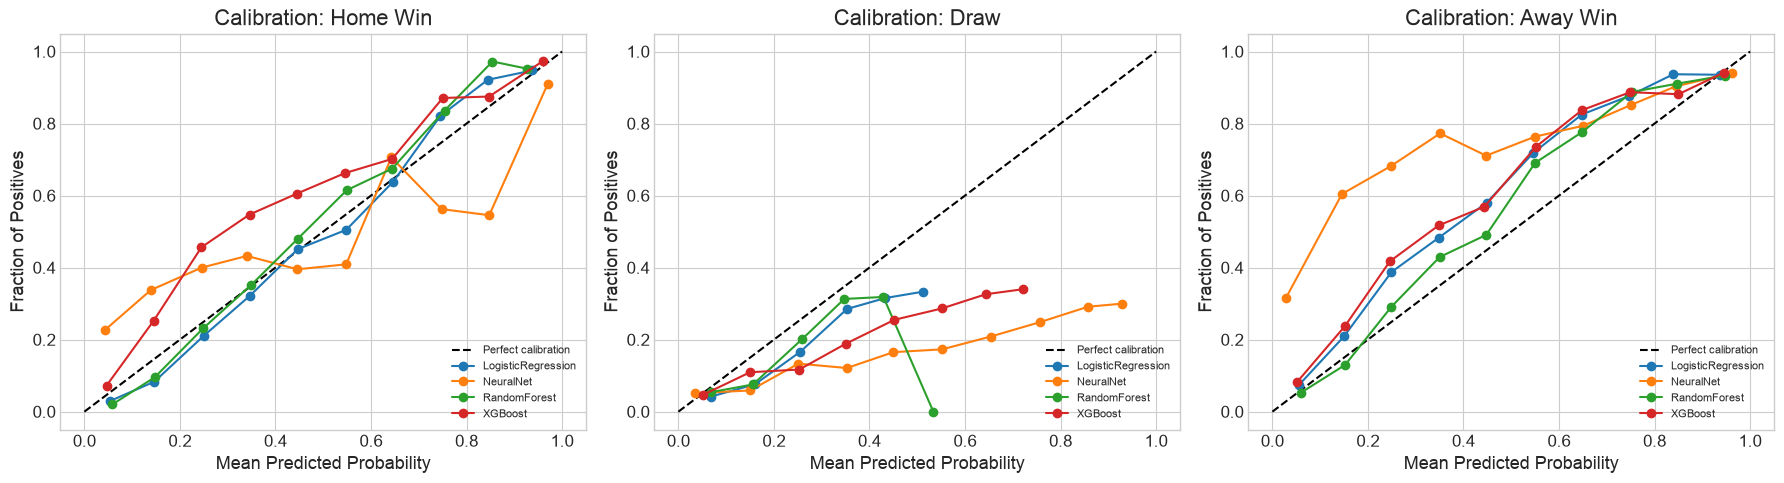

In [7]:
plot_calibration_curves(all_results, X_test, y_test)
plt.show()

## 5. Best Model (Ensemble)

In [8]:
best_model = joblib.load(models_dir / 'best_model.joblib')
best_results = evaluate_model(best_model, X_test, y_test, 'Best Ensemble')
print(f'Best model type: {type(best_model).__name__}')
print(f'Best model accuracy: {best_results["accuracy"]:.4f}')
print(f'Best model log loss: {best_results["log_loss"]:.4f}')

2026-07-01 11:39:28,113 [INFO] worldcup: Evaluating Best Ensemble...
2026-07-01 11:39:28,179 [INFO] worldcup:   Accuracy: 0.6148
2026-07-01 11:39:28,179 [INFO] worldcup:   Log Loss: 0.8352
2026-07-01 11:39:28,179 [INFO] worldcup:   Brier Scores: {'away_win': 0.14357703035859662, 'draw': 0.17233698747826703, 'home_win': 0.17412548021150975}


Best model type: VotingClassifier
Best model accuracy: 0.6148
Best model log loss: 0.8352
